# 3.2 Clustering (Descriptive Analytics)

This notebook develops and evaluates clustering solutions for the Spotify tracks dataset. The analysis uses k-means and DBSCAN, and also includes optimisation experiments to compare multiple preprocessing and modelling strategies before selecting the most balanced final solution.


## 3.2.1 Objective

The objective of this section is to identify natural groupings within the dataset using unsupervised learning techniques. Clustering is applied to group tracks based on their audio features without using the provided genre labels.

Two required clustering algorithms are explored: k-means and DBSCAN. In addition, several optimisation strategies are tested to improve clustering performance, including feature selection, dimensionality reduction, feature engineering, an alternative scaling approach, and additional clustering models.

The aim is to determine whether meaningful structure exists in the data, assess how well the resulting clusters align with known genre information, and identify a stable and interpretable clustering solution.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    adjusted_rand_score,
    normalized_mutual_info_score
)
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 3.2.2 Data Loading and Initial Checks

The dataset is loaded and checked for structure, missing values, and genre distribution. Although `track_genre` is not used for clustering, it is still useful later when evaluating whether the unsupervised structure aligns with the known labels.


In [2]:
file_path = "../data/tracks2026.csv"
df = pd.read_csv(file_path)

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum())

print("\nGenre counts:")
print(df["track_genre"].value_counts())

Shape: (2000, 17)

Columns:
['track_id', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']

Missing values:
track_id             0
popularity          40
duration_ms          0
explicit             0
danceability        40
energy              40
key                  0
loudness            39
mode                 0
speechiness          0
acousticness         0
instrumentalness     0
liveness             0
valence              0
tempo               40
time_signature       0
track_genre          0
dtype: int64

Genre counts:
track_genre
pop          500
indie-pop    500
synth-pop    400
r-n-b        300
hip-hop      300
Name: count, dtype: int64


## 3.2.3 Data Preparation

The column `track_genre` was removed prior to clustering in accordance with the specification, ensuring that the analysis is performed independently of known labels. The identifier column `track_id` was also excluded because it does not contain meaningful structure for clustering.

Feature selection was informed by the exploratory data analysis conducted earlier (see Section 3.1). In particular, the EDA indicated that continuous audio features such as energy, danceability, acousticness, speechiness, valence, tempo, and loudness exhibit meaningful variation across tracks and are therefore suitable for clustering.

In contrast, variables such as `key`, `mode`, and `time_signature` were observed to have limited variability or to represent categorical structure, making them less appropriate for distance-based methods. The variable `duration_ms` was also excluded because it is less directly related to musical style than the core audio features.

Missing values were handled using median imputation, and all retained features were standardised. This is essential because both k-means and DBSCAN rely on distance calculations and would otherwise be dominated by variables with larger scales.

A train/test split was not applied, as clustering is an unsupervised task and does not involve predicting a target variable. Instead, cluster quality is evaluated using internal metrics, visual inspection, and external comparison with genre labels.


In [3]:
genre_labels = df["track_genre"].copy()

X = df.drop(columns=["track_genre", "track_id"]).copy()

if "explicit" in X.columns:
    X["explicit"] = X["explicit"].astype(int)

cols_to_drop = ["key", "mode", "time_signature", "duration_ms"]
X = X.drop(columns=cols_to_drop, errors="ignore")

selected_features = X.columns.tolist()

preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X_scaled = preprocessor.fit_transform(X)

print("Features used for clustering:")
print(selected_features)
print("\nNumber of features:", len(selected_features))
print("Processed shape:", X_scaled.shape)

Features used for clustering:
['popularity', 'explicit', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

Number of features: 11
Processed shape: (2000, 11)


One useful point here is that the retained variables are mostly continuous audio features, which makes them much more suitable for distance-based grouping than categorical musical tags.


## 3.2.4 Dimensionality Reduction with PCA

Principal Component Analysis (PCA) was applied to reduce dimensionality while preserving 90% of the variance. This reduces noise and lessens the effect of dimensionality, which can negatively affect both centroid-based and density-based clustering methods.

The transformation provides a more compact representation of the data while retaining most of the original information.


In [4]:
pca_model = PCA(n_components=0.90, random_state=RANDOM_STATE)
X_pca_full = pca_model.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("PCA-reduced shape:", X_pca_full.shape)
print("Explained variance retained:", pca_model.explained_variance_ratio_.sum())
print("Number of PCA components:", pca_model.n_components_)

Original shape: (2000, 11)
PCA-reduced shape: (2000, 9)
Explained variance retained: 0.9273168243329243
Number of PCA components: 9


This step matters because the dataset is not especially easy to cluster cleanly, and PCA helps reduce overlap between correlated features while still keeping most of the useful structure.


## 3.2.5 k-Means Model Selection

The value of k was explored across a range of cluster counts. Performance was compared on both the scaled feature space and the PCA-reduced feature space using the silhouette score.

This comparison helps determine whether dimensionality reduction improves cluster separation and whether the apparent best value of k is stable and interpretable.


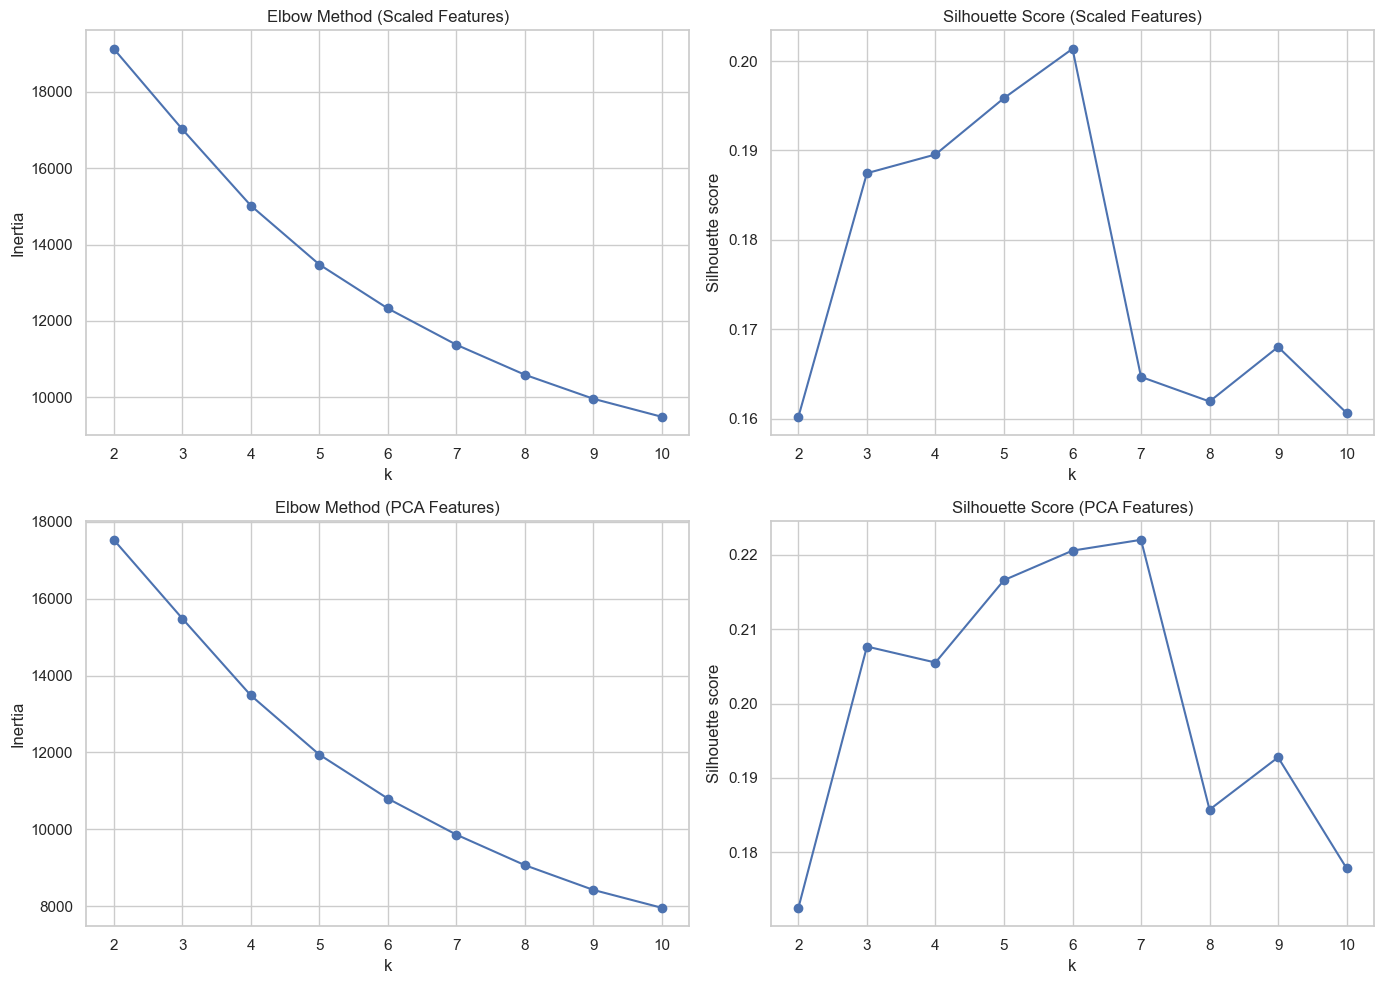

,k,silhouette_scaled,silhouette_pca
0,2,0.160231,0.172550
1,3,0.187464,0.207654
2,4,0.189556,0.205505
3,5,0.195855,0.216574
4,6,0.201365,0.220541
5,7,0.164697,0.221993
6,8,0.161948,0.185744
7,9,0.168040,0.192770
8,10,0.160666,0.177865


In [5]:
k_values = range(2, 11)

raw_inertias = []
raw_silhouettes = []
pca_inertias = []
pca_silhouettes = []

for k in k_values:
    km_raw = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=50)
    raw_labels = km_raw.fit_predict(X_scaled)
    raw_inertias.append(km_raw.inertia_)
    raw_silhouettes.append(silhouette_score(X_scaled, raw_labels))

    km_pca = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=50)
    pca_labels = km_pca.fit_predict(X_pca_full)
    pca_inertias.append(km_pca.inertia_)
    pca_silhouettes.append(silhouette_score(X_pca_full, pca_labels))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(k_values, raw_inertias, marker="o")
axes[0, 0].set_title("Elbow Method (Scaled Features)")
axes[0, 0].set_xlabel("k")
axes[0, 0].set_ylabel("Inertia")

axes[0, 1].plot(k_values, raw_silhouettes, marker="o")
axes[0, 1].set_title("Silhouette Score (Scaled Features)")
axes[0, 1].set_xlabel("k")
axes[0, 1].set_ylabel("Silhouette score")

axes[1, 0].plot(k_values, pca_inertias, marker="o")
axes[1, 0].set_title("Elbow Method (PCA Features)")
axes[1, 0].set_xlabel("k")
axes[1, 0].set_ylabel("Inertia")

axes[1, 1].plot(k_values, pca_silhouettes, marker="o")
axes[1, 1].set_title("Silhouette Score (PCA Features)")
axes[1, 1].set_xlabel("k")
axes[1, 1].set_ylabel("Silhouette score")

plt.tight_layout()
plt.show()

comparison_df = pd.DataFrame({
    "k": list(k_values),
    "silhouette_scaled": raw_silhouettes,
    "silhouette_pca": pca_silhouettes
})

comparison_df

The PCA-based approach gave higher silhouette scores than clustering on the full scaled feature space for the k-means comparison, which suggests that dimensionality reduction helps reduce noise and redundancy in this dataset.

For k-means, `n_init = 50` was used throughout to make the model more stable and less sensitive to random centroid starting points.

Even though the silhouette score keeps increasing for some larger values of k, those solutions still need to be checked for stability and interpretability. For that reason, a smaller set of candidate values is looked at more closely.


In [6]:
candidate_ks = [3, 4, 5]

kmeans_results = {}

for k in candidate_ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=50)
    labels_k = km.fit_predict(X_pca_full)

    kmeans_results[k] = {
        "model": km,
        "labels": labels_k,
        "silhouette": silhouette_score(X_pca_full, labels_k),
        "cluster_sizes": pd.Series(labels_k).value_counts().sort_index()
    }

for k in candidate_ks:
    print(f"k = {k}")
    print(f"Silhouette score: {kmeans_results[k]['silhouette']:.4f}")
    print(kmeans_results[k]["cluster_sizes"])
    print("-" * 50)

k = 3
Silhouette score: 0.2077
0     223
1     614
2    1163
Name: count, dtype: int64
--------------------------------------------------
k = 4
Silhouette score: 0.2055
0     612
1    1164
2     223
3       1
Name: count, dtype: int64
--------------------------------------------------
k = 5
Silhouette score: 0.2166
0     221
1       1
2     593
3      54
4    1131
Name: count, dtype: int64
--------------------------------------------------


### Candidate Cluster Visualisation

The candidate k-means solutions are visualised using the first two principal components. This low-dimensional view is used for interpretation only; clustering itself is performed on the full PCA-reduced feature space.


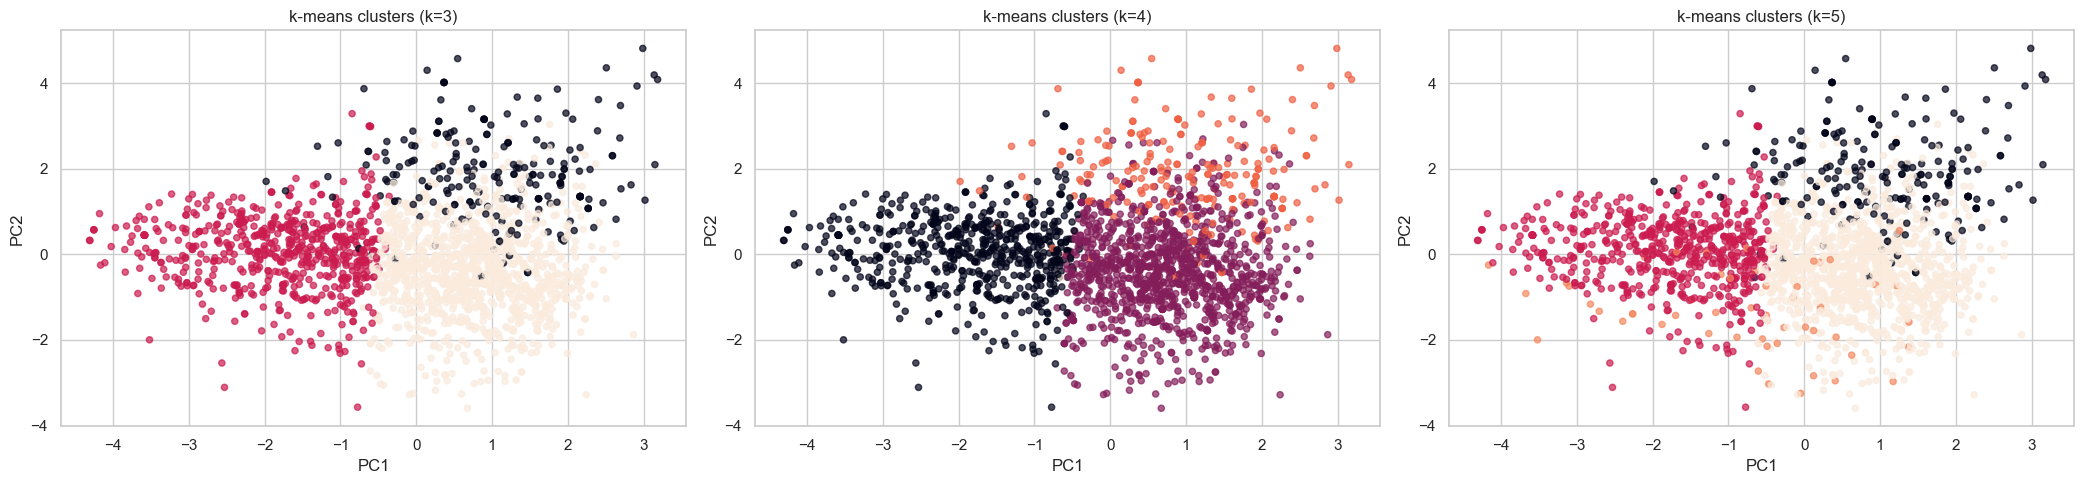

Explained variance by plotting PCA (2 PCs): 0.3186971756423398


In [7]:
plot_pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_plot = plot_pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, len(candidate_ks), figsize=(7 * len(candidate_ks), 5))

if len(candidate_ks) == 1:
    axes = [axes]

for ax, k in zip(axes, candidate_ks):
    labels_k = kmeans_results[k]["labels"]
    ax.scatter(X_plot[:, 0], X_plot[:, 1], c=labels_k, s=20, alpha=0.7)
    ax.set_title(f"k-means clusters (k={k})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()

print("Explained variance by plotting PCA (2 PCs):", plot_pca.explained_variance_ratio_.sum())

A good summary here is that k = 3 gives the best balance between separation, cluster size balance, and interpretability among the candidate values tested.


### Final k-Means Selection

The final value of k is selected by balancing silhouette score, cluster size stability, and interpretability. Degenerate solutions with extremely small clusters are rejected, even if they achieve a slightly higher numerical score.


In [8]:
valid_results = []

for k in candidate_ks:
    sizes = kmeans_results[k]["cluster_sizes"]
    if sizes.min() > 20:
        valid_results.append((k, kmeans_results[k]["silhouette"]))

chosen_k = sorted(valid_results, key=lambda x: x[1], reverse=True)[0][0]

final_kmeans = KMeans(n_clusters=chosen_k, random_state=RANDOM_STATE, n_init=50)
final_kmeans_labels = final_kmeans.fit_predict(X_pca_full)

final_silhouette = silhouette_score(X_pca_full, final_kmeans_labels)

print("Chosen k:", chosen_k)
print("Final silhouette score:", final_silhouette)

print("\nCluster sizes:")
print(pd.Series(final_kmeans_labels).value_counts().sort_index())

print("\nCluster proportions:")
print(pd.Series(final_kmeans_labels).value_counts(normalize=True).round(3))

Chosen k: 3
Final silhouette score: 0.20765437131178016

Cluster sizes:
0     223
1     614
2    1163
Name: count, dtype: int64

Cluster proportions:
2    0.582
1    0.307
0    0.112
Name: proportion, dtype: float64


Although some larger values of k produced slightly higher silhouette scores, they also produced highly imbalanced or degenerate clusters. By contrast, k = 3 gave a more stable and interpretable structure. This shows that the final clustering solution should not be chosen using numerical criteria alone.


## 3.2.6 Cluster Interpretation

The clusters are interpreted using the average standardised feature values within each cluster. This helps identify the musical characteristics associated with each group and assess whether the clustering reveals meaningful structure in the data.


In [9]:
cluster_profiles_z = pd.DataFrame(X_scaled, columns=selected_features)
cluster_profiles_z["cluster"] = final_kmeans_labels
cluster_profiles_z = cluster_profiles_z.groupby("cluster").mean().round(3)

feature_variance = cluster_profiles_z.var().sort_values(ascending=False)
cluster_profiles_z = cluster_profiles_z[feature_variance.index]

cluster_profiles_z

,explicit,acousticness,energy,valence,danceability,speechiness,tempo,popularity,instrumentalness,liveness,loudness
cluster,,,,,,,,,,,
0,2.809,-0.438,0.006,-0.254,0.591,0.779,0.049,-0.008,-0.162,0.002,-0.022
1,-0.349,0.957,-0.954,-0.775,-0.605,-0.363,-0.276,0.209,0.075,-0.119,0.050
2,-0.354,-0.421,0.503,0.458,0.206,0.042,0.137,-0.109,-0.009,0.062,-0.022


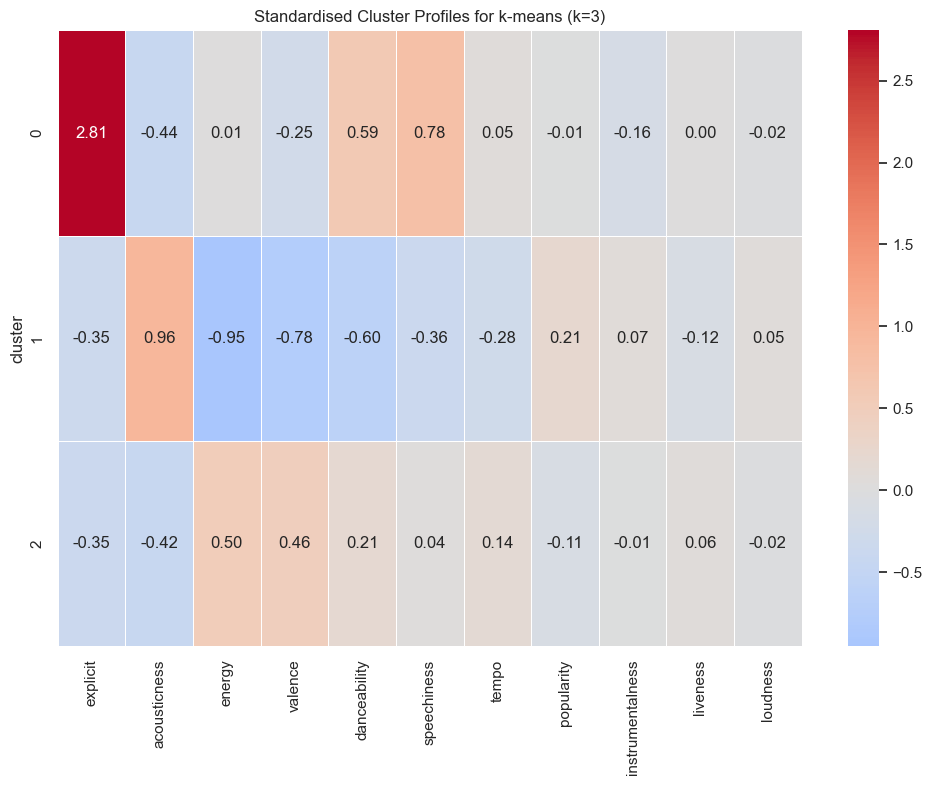

In [10]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    cluster_profiles_z,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)
plt.title(f"Standardised Cluster Profiles for k-means (k={chosen_k})")
plt.show()

The cluster profiles reveal clear differences in audio characteristics:

- Cluster 0 has very high speechiness and explicit content, which suggests speech-driven tracks and a strong presence of hip-hop-like examples.
- Cluster 1 shows high acousticness and low energy, which fits acoustic or lower-intensity tracks.
- Cluster 2 has comparatively higher energy and valence, which suggests a more upbeat profile.

These patterns suggest that the clustering is capturing meaningful musical variation rather than arbitrary groupings.


In [11]:
cluster_names = {
    0: "Speech-driven / Explicit",
    1: "Acoustic / Low-energy",
    2: "Energetic / Mainstream"
}

named_profiles = cluster_profiles_z.copy()
named_profiles.index = [cluster_names.get(i, f"Cluster {i}") for i in named_profiles.index]
named_profiles

,explicit,acousticness,energy,valence,danceability,speechiness,tempo,popularity,instrumentalness,liveness,loudness
Speech-driven / Explicit,2.809,-0.438,0.006,-0.254,0.591,0.779,0.049,-0.008,-0.162,0.002,-0.022
Acoustic / Low-energy,-0.349,0.957,-0.954,-0.775,-0.605,-0.363,-0.276,0.209,0.075,-0.119,0.050
Energetic / Mainstream,-0.354,-0.421,0.503,0.458,0.206,0.042,0.137,-0.109,-0.009,0.062,-0.022


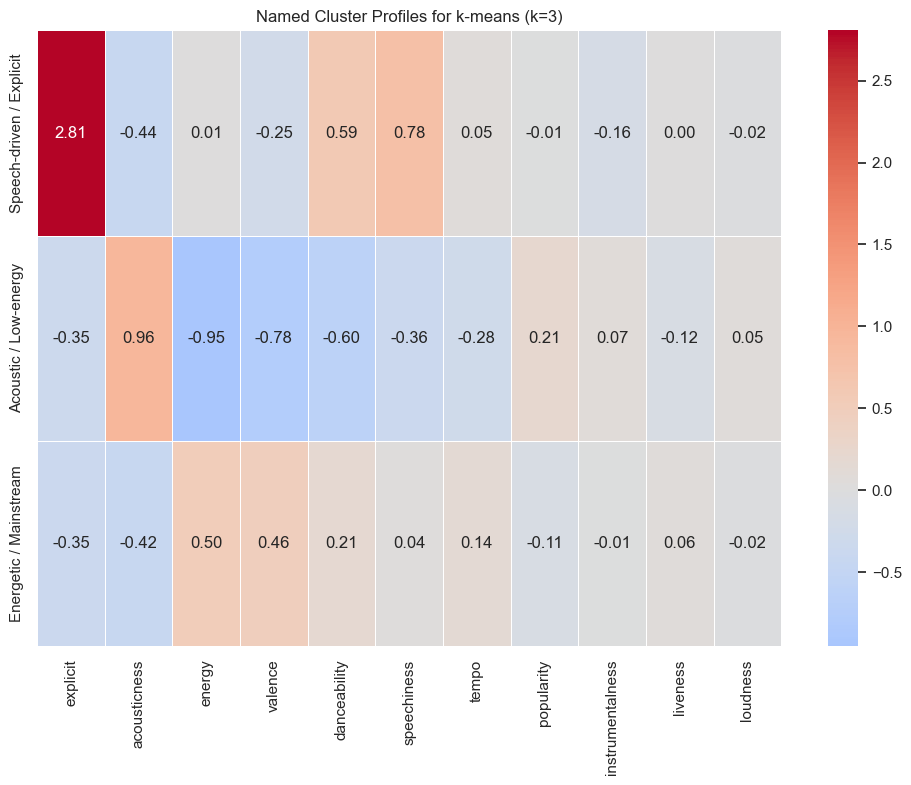

In [12]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    named_profiles,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)
plt.title(f"Named Cluster Profiles for k-means (k={chosen_k})")
plt.show()

A simple way to describe the final result is that the clusters separate the dataset into speech-driven tracks, acoustic or lower-energy tracks, and more upbeat tracks with higher energy and valence.


## 3.2.7 Comparison with Genre Information

Although `track_genre` was not used during clustering, it is useful afterwards for checking whether the discovered groups align with the known genre labels. This provides an external perspective on the clustering solution, while recognising that genre labels and audio-feature structure are not necessarily the same thing.


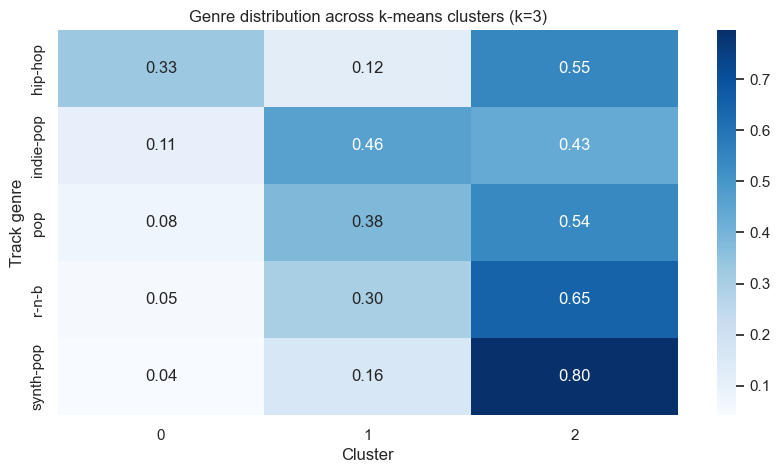

col_0,0,1,2
track_genre,,,
hip-hop,0.330000,0.123333,0.546667
indie-pop,0.106000,0.462000,0.432000
pop,0.076000,0.382000,0.542000
r-n-b,0.053333,0.300000,0.646667
synth-pop,0.042500,0.162500,0.795000


In [13]:
genre_vs_cluster = pd.crosstab(
    df["track_genre"],
    final_kmeans_labels,
    normalize="index"
)

plt.figure(figsize=(10, 5))
sns.heatmap(genre_vs_cluster, annot=True, cmap="Blues", fmt=".2f")
plt.title(f"Genre distribution across k-means clusters (k={chosen_k})")
plt.xlabel("Cluster")
plt.ylabel("Track genre")
plt.show()

genre_vs_cluster

In [14]:
ari_kmeans = adjusted_rand_score(df["track_genre"], final_kmeans_labels)
nmi_kmeans = normalized_mutual_info_score(df["track_genre"], final_kmeans_labels)

print(f"Adjusted Rand Index: {ari_kmeans:.4f}")
print(f"Normalized Mutual Information: {nmi_kmeans:.4f}")

Adjusted Rand Index: 0.0314
Normalized Mutual Information: 0.0589


The alignment with genre labels is limited, as shown by the low ARI and NMI scores. However, this does not mean that the clustering is uninformative. Genre labels are broad and culturally defined, while the clustering is based only on numerical audio features. Tracks from different genres can share similar acoustic properties, and tracks within the same genre can vary a lot.

Because of that, the clusters should be understood as showing audio-based structure rather than reproducing genre labels exactly.


## 3.2.8 Additional k-Means Evaluation

To better understand the internal quality of the final k-means solution, centroid locations in PCA space and the distribution of silhouette scores across samples are examined.


In [15]:
centroids = pd.DataFrame(
    final_kmeans.cluster_centers_,
    columns=[f"PC{i+1}" for i in range(final_kmeans.cluster_centers_.shape[1])]
)

centroids

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
0,1.027666,1.874806,1.656975,0.231619,-0.398825,0.257257,-0.403294,-0.568397,-0.902393
1,-1.779675,0.051927,-0.007837,-0.059968,0.054311,0.009120,0.079934,0.062201,0.016695
2,0.742520,-0.386900,-0.313580,-0.012752,0.047800,-0.054143,0.035129,0.076149,0.164216


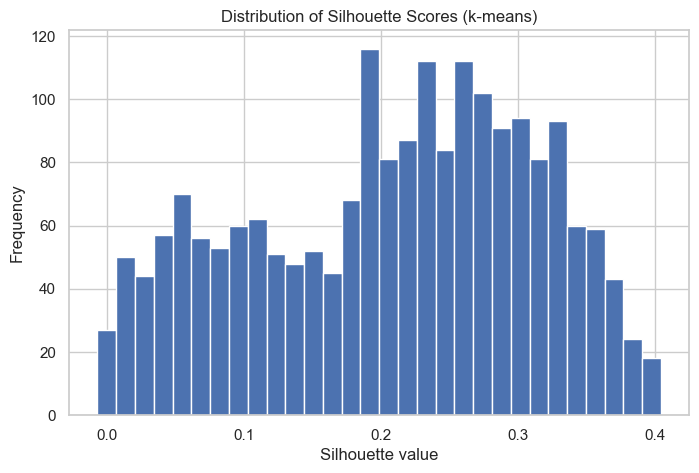

In [16]:
sample_silhouette = silhouette_samples(X_pca_full, final_kmeans_labels)

plt.figure(figsize=(8, 5))
plt.hist(sample_silhouette, bins=30)
plt.title("Distribution of Silhouette Scores (k-means)")
plt.xlabel("Silhouette value")
plt.ylabel("Frequency")
plt.show()

The silhouette distribution shows modest but meaningful separation. That is in line with what would be expected for a difficult real-world music dataset, where clusters are not perfectly separated and genres overlap acoustically.


## 3.2.9 Clustering Optimisation Experiments

Because this dataset is challenging, several optimisation strategies were explored to maximise clustering performance and to demonstrate that the final solution was chosen after meaningful experimentation rather than by default.


### Experiment 1: Remove Popularity

`popularity` is not an audio feature, so it may introduce non-musical variation into the clustering. This experiment tests whether removing it improves cluster quality.


In [17]:
X_no_pop = X.drop(columns=["popularity"], errors="ignore")

X_no_pop_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
]).fit_transform(X_no_pop)

X_no_pop_pca = PCA(n_components=0.90, random_state=RANDOM_STATE).fit_transform(X_no_pop_scaled)

labels_no_pop = KMeans(n_clusters=3, n_init=50, random_state=RANDOM_STATE).fit_predict(X_no_pop_pca)

sil_no_pop = silhouette_score(X_no_pop_pca, labels_no_pop)
print("Silhouette (no popularity):", sil_no_pop)

Silhouette (no popularity): 0.23974994489899928


### Experiment 2: PCA vs No PCA

This experiment directly compares clustering on the full scaled feature space with clustering on the PCA-reduced feature space.


In [18]:
labels_raw_k3 = KMeans(n_clusters=3, n_init=50, random_state=RANDOM_STATE).fit_predict(X_scaled)

sil_raw_k3 = silhouette_score(X_scaled, labels_raw_k3)
sil_pca_k3 = silhouette_score(X_pca_full, final_kmeans_labels)

print("Silhouette (raw scaled features):", sil_raw_k3)
print("Silhouette (PCA features):", sil_pca_k3)

Silhouette (raw scaled features): 0.18746364773637872
Silhouette (PCA features): 0.20765437131178016


### Experiment 3: Gaussian Mixture Model (GMM)

A Gaussian Mixture Model was tested as an alternative clustering approach. Unlike k-means, GMM allows clusters to take more flexible elliptical shapes.


In [19]:
gmm = GaussianMixture(n_components=3, random_state=RANDOM_STATE)
gmm_labels = gmm.fit_predict(X_pca_full)

sil_gmm = silhouette_score(X_pca_full, gmm_labels)
print("GMM Silhouette:", sil_gmm)

GMM Silhouette: 0.24665487377534753


### Experiment 4: Agglomerative Clustering

Agglomerative hierarchical clustering was also explored. This method builds clusters progressively by merging nearby observations and provides a useful comparison with centroid-based clustering.


In [20]:
agg = AgglomerativeClustering(n_clusters=3)
agg_labels = agg.fit_predict(X_pca_full)

sil_agg = silhouette_score(X_pca_full, agg_labels)
print("Agglomerative Silhouette:", sil_agg)

Agglomerative Silhouette: 0.25760696889011725


### Experiment 5: Alternative Scaling

An alternative scaling approach using `MinMaxScaler` was tested to check whether rescaling the features to the [0, 1] range produces better separation than standardisation.


In [21]:
minmax_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

X_minmax = minmax_pipeline.fit_transform(X)
X_minmax_pca = PCA(n_components=0.90, random_state=RANDOM_STATE).fit_transform(X_minmax)

labels_minmax = KMeans(n_clusters=3, n_init=50, random_state=RANDOM_STATE).fit_predict(X_minmax_pca)

sil_minmax = silhouette_score(X_minmax_pca, labels_minmax)
print("Silhouette (MinMaxScaler):", sil_minmax)

Silhouette (MinMaxScaler): 0.262954493587326


### Experiment 6: Simple Feature Engineering

A logarithmic transformation was applied to `tempo` to test whether reducing skewness improves cluster quality.


In [22]:
X_fe = X.copy()
X_fe["tempo_log"] = np.log1p(X_fe["tempo"])
X_fe = X_fe.drop(columns=["tempo"])

X_fe_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
]).fit_transform(X_fe)

X_fe_pca = PCA(n_components=0.90, random_state=RANDOM_STATE).fit_transform(X_fe_scaled)

labels_fe = KMeans(n_clusters=3, n_init=50, random_state=RANDOM_STATE).fit_predict(X_fe_pca)

sil_fe = silhouette_score(X_fe_pca, labels_fe)
print("Silhouette (feature engineered):", sil_fe)

Silhouette (feature engineered): 0.2055644971666293


In [23]:
optimisation_summary = pd.DataFrame({
    "experiment": [
        "Final k-means (StandardScaler + PCA)",
        "Remove popularity",
        "k-means without PCA",
        "Gaussian Mixture Model",
        "Agglomerative clustering",
        "MinMaxScaler + PCA",
        "Tempo log feature engineering"
    ],
    "silhouette": [
        final_silhouette,
        sil_no_pop,
        sil_raw_k3,
        sil_gmm,
        sil_agg,
        sil_minmax,
        sil_fe
    ]
}).sort_values(by="silhouette", ascending=False)

optimisation_summary

,experiment,silhouette
5,MinMaxScaler + PCA,0.262954
4,Agglomerative clustering,0.257607
3,Gaussian Mixture Model,0.246655
1,Remove popularity,0.239750
0,Final k-means (StandardScaler + PCA),0.207654
6,Tempo log feature engineering,0.205564
2,k-means without PCA,0.187464


The optimisation experiments show that a number of strategies were tried to improve clustering performance. PCA improved the k-means solution relative to clustering on the raw scaled features. However, some alternatives such as `MinMaxScaler + PCA`, agglomerative clustering, and a Gaussian Mixture Model achieved higher silhouette scores than the final k-means configuration. The final pipeline was therefore chosen as a balance between internal quality, cluster stability, and interpretability rather than as the single best model by silhouette score alone.


## 3.2.10 DBSCAN Clustering

DBSCAN was explored as an alternative clustering method because it does not require the number of clusters to be specified in advance and can identify noise points. Since DBSCAN is sensitive to dimensionality, it was applied to the PCA-reduced feature space.

Its parameters were tuned using both the 5-nearest-neighbour distance plot and a small grid of eps and min_samples values.


### Why DBSCAN Was Included

DBSCAN was tested as a comparison method because it can discover clusters of irregular shape and does not require the number of clusters to be specified in advance. It is also useful for identifying noise points or tracks that do not fit neatly into any cluster.

Because DBSCAN is sensitive to scale and dimensionality, it is applied here after imputation, standardisation, and PCA. The goal is to see whether the dataset contains density-based structure as well as centroid-based structure.


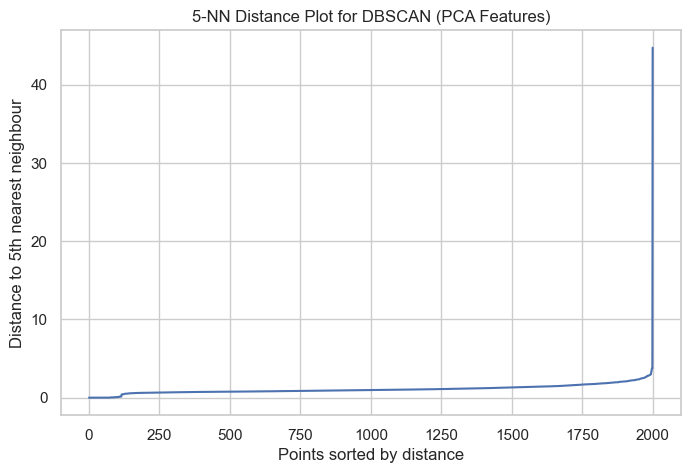

In [24]:
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_pca_full)
distances, _ = neighbors_fit.kneighbors(X_pca_full)

k_distances = np.sort(distances[:, 4])

plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.title("5-NN Distance Plot for DBSCAN (PCA Features)")
plt.xlabel("Points sorted by distance")
plt.ylabel("Distance to 5th nearest neighbour")
plt.show()

In [25]:
dbscan_configs = [
    {"eps": 0.8, "min_samples": 5},
    {"eps": 1.0, "min_samples": 5},
    {"eps": 1.2, "min_samples": 5},
    {"eps": 1.0, "min_samples": 10},
    {"eps": 1.2, "min_samples": 10},
    {"eps": 1.4, "min_samples": 10},
]

dbscan_results = []

for config in dbscan_configs:
    db = DBSCAN(eps=config["eps"], min_samples=config["min_samples"])
    db_labels_tmp = db.fit_predict(X_pca_full)

    n_clusters = len(set(db_labels_tmp)) - (1 if -1 in db_labels_tmp else 0)
    noise_ratio = np.mean(db_labels_tmp == -1)

    if n_clusters > 1:
        mask_tmp = db_labels_tmp != -1
        if len(set(db_labels_tmp[mask_tmp])) > 1:
            sil = silhouette_score(X_pca_full[mask_tmp], db_labels_tmp[mask_tmp])
        else:
            sil = np.nan
    else:
        sil = np.nan

    dbscan_results.append({
        "eps": config["eps"],
        "min_samples": config["min_samples"],
        "n_clusters": n_clusters,
        "noise_ratio": noise_ratio,
        "silhouette": sil
    })

dbscan_results_df = pd.DataFrame(dbscan_results).sort_values(
    by=["silhouette", "noise_ratio"],
    ascending=[False, True]
)

dbscan_results_df

,eps,min_samples,n_clusters,noise_ratio,silhouette
4,1.2,10,4,0.3035,0.186377
5,1.4,10,7,0.1990,0.139219
2,1.2,5,12,0.2245,0.047284
3,1.0,10,6,0.4895,-0.043252
1,1.0,5,17,0.3570,-0.122005
0,0.8,5,26,0.5790,-0.170029


### DBSCAN Evaluation Notes

For DBSCAN, the main things to watch are the number of clusters found, the proportion of points labelled as noise, and the silhouette score computed on the non-noise points. A configuration with many clusters but a very high noise ratio is usually less useful than a slightly simpler configuration with better coverage.

The 5-nearest-neighbour distance plot and the small parameter grid are used here to choose a reasonable `eps` and `min_samples` combination rather than tuning DBSCAN blindly.


In [26]:
valid_dbscan = dbscan_results_df[
    (dbscan_results_df["noise_ratio"] < 0.4) &
    (dbscan_results_df["n_clusters"] >= 2)
]

best_row = valid_dbscan.iloc[0]

best_dbscan = DBSCAN(
    eps=best_row["eps"],
    min_samples=int(best_row["min_samples"])
)

print("Selected DBSCAN config:")
print(best_row)

Selected DBSCAN config:
eps             1.200000
min_samples    10.000000
n_clusters      4.000000
noise_ratio     0.303500
silhouette      0.186377
Name: 4, dtype: float64


In [27]:
db_labels = best_dbscan.fit_predict(X_pca_full)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
noise_ratio_db = np.mean(db_labels == -1)

print("Clusters found:", n_clusters_db)
print("Noise proportion:", noise_ratio_db)

Clusters found: 4
Noise proportion: 0.3035


### Interpreting The DBSCAN Result

In the final result, DBSCAN identifies some structure, but it also labels a substantial share of tracks as noise. That suggests the dataset does not contain very strong density-separated groups, even after PCA-based preprocessing.

This makes DBSCAN useful as a comparison method, but weaker than k-means as the final clustering choice for this dataset.


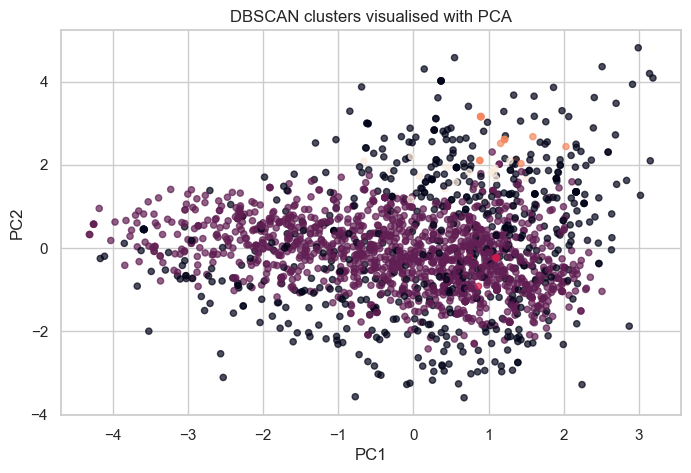

In [28]:
plt.figure(figsize=(8, 5))
plt.scatter(X_plot[:, 0], X_plot[:, 1], c=db_labels, s=20, alpha=0.7)
plt.title("DBSCAN clusters visualised with PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [29]:
mask = db_labels != -1

if len(set(db_labels[mask])) > 1:
    ari_db = adjusted_rand_score(df.loc[mask, "track_genre"], db_labels[mask])
    nmi_db = normalized_mutual_info_score(df.loc[mask, "track_genre"], db_labels[mask])
    print(f"DBSCAN ARI (excluding noise): {ari_db:.4f}")
    print(f"DBSCAN NMI (excluding noise): {nmi_db:.4f}")
else:
    ari_db = np.nan
    nmi_db = np.nan
    print("DBSCAN did not produce enough non-noise clusters for external comparison.")

DBSCAN ARI (excluding noise): 0.0098
DBSCAN NMI (excluding noise): 0.0482


DBSCAN produced a workable configuration after PCA-based preprocessing, but it still classified a large proportion of tracks as noise and produced lower external alignment than k-means. This suggests that the dataset does not have strongly density-separated structure, which makes DBSCAN less suitable as the final clustering method.


## 3.2.11 Final Comparison and Conclusion

The final comparison summarises the performance of the selected k-means and DBSCAN solutions.


In [30]:
kmeans_sil = silhouette_score(X_pca_full, final_kmeans_labels)

summary_rows = [{
    "method": f"k-means (k={chosen_k})",
    "n_clusters": len(np.unique(final_kmeans_labels)),
    "noise_ratio": 0.0,
    "silhouette": kmeans_sil,
    "ARI": ari_kmeans,
    "NMI": nmi_kmeans
}]

if len(set(db_labels[mask])) > 1:
    db_sil = silhouette_score(X_pca_full[mask], db_labels[mask])
    summary_rows.append({
        "method": f"DBSCAN (eps={best_dbscan.eps}, min_samples={best_dbscan.min_samples})",
        "n_clusters": n_clusters_db,
        "noise_ratio": noise_ratio_db,
        "silhouette": db_sil,
        "ARI": ari_db,
        "NMI": nmi_db
    })
else:
    summary_rows.append({
        "method": f"DBSCAN (eps={best_dbscan.eps}, min_samples={best_dbscan.min_samples})",
        "n_clusters": n_clusters_db,
        "noise_ratio": noise_ratio_db,
        "silhouette": np.nan,
        "ARI": np.nan,
        "NMI": np.nan
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,method,n_clusters,noise_ratio,silhouette,ARI,NMI
0,k-means (k=3),3,0.0000,0.207654,0.031396,0.058901
1,"DBSCAN (eps=1.2, min_samples=10)",4,0.3035,0.186377,0.009773,0.048222


Overall, k-means with k = 3 provided the most balanced clustering solution for this dataset. It produced stable, interpretable clusters that captured meaningful differences in audio characteristics, while also outperforming DBSCAN on the main evaluation measures used here.

The optimisation experiments also show that multiple strategies were tested to improve performance, including feature selection, PCA, alternative scaling, feature engineering, hierarchical clustering, and probabilistic clustering. Even though the dataset is challenging and does not produce perfectly separated clusters, the final solution is well justified and carefully evaluated.


A concise overall interpretation is that the dataset contains real but overlapping structure: enough to support meaningful clustering, but not enough to expect perfect separation or exact reproduction of genre labels.
